In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Feature Engineering

In [37]:
train_data = pd.read_csv('../data/train.csv')
test_data = pd.read_csv('../data/test.csv')

In [38]:
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


#First I will be replacing the name with titles and do one-hot encoding

In [39]:
train_test = [train_data, test_data]

for dataset in train_test:
    dataset['Title'] = (dataset['Name']
    .str.extract(' ([A-Za-z]+)\.', expand=False)
    .replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], "Rare")
    .replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}))



<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/17/dwmdxgxd6f3d9tws818t6_8c0000gp/T/ipykernel_85277/2511203872.py:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  .str.extract(' ([A-Za-z]+)\.', expand=False)


In [40]:
print(train_data['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64


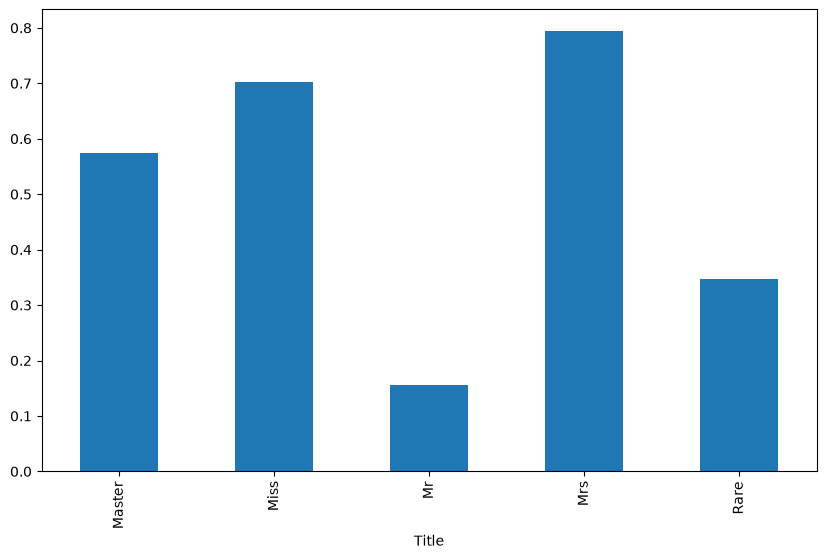

In [41]:
print(train_data.groupby('Title')['Survived'].mean())
train_data.groupby('Title')['Survived'].mean().plot(kind='bar', figsize=(10, 6))
plt.show()

#-> Master and Miss/Mrs has high survival rate

In [42]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [43]:
#filling age na by finding median from Title before one hot encoding -> one hot is better for logistic regression
train_data['Age'] = train_data['Age'].fillna(train_data.groupby('Title')['Age'].transform('median'))
test_data['Age'] = test_data['Age'].fillna(test_data.groupby('Title')['Age'].transform('median'))

train_data = pd.get_dummies(train_data, columns=["Title"],dtype=int)
test_data = pd.get_dummies(test_data, columns=["Title"],dtype=int)
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,0


In [44]:
train_data['Sex'] = train_data['Sex'].replace({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].replace({'male': 0, 'female': 1})
train_data.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,0
5,6,0,3,"Moran, Mr. James",0,30.0,0,0,330877,8.4583,NaN,Q,0,0,1,0,0
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,E46,S,0,0,1,0,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,NaN,S,1,0,0,0,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,NaN,S,0,0,0,1,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,NaN,C,0,0,0,1,0


In [45]:
train_data = train_data.drop('Name', axis=1)
test_data = test_data.drop('Name', axis=1)
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,0
1,2,1,1,1,38.0,1,0,PC 17599,71.2833,C85,C,0,0,0,1,0
2,3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0
3,4,1,1,1,35.0,1,0,113803,53.1000,C123,S,0,0,0,1,0
4,5,0,3,0,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,0


In [46]:
drop_cols = ['Ticket', 'Cabin', 'PassengerId']
train_data = train_data.drop(drop_cols, axis=1)
test_data = test_data.drop(drop_cols, axis=1)

train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,S,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,C,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,S,0,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,S,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,S,0,0,1,0,0


In [47]:
# fill null embarked cell with "S" because its the most common

train_data['Embarked'] = train_data['Embarked'].fillna('S')

In [48]:
test_data['Fare'] = test_data['Fare'].fillna(test_data.groupby('Pclass')['Fare'].transform('median'))
test_data.isnull().sum()

Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Title_Master    0
Title_Miss      0
Title_Mr        0
Title_Mrs       0
Title_Rare      0
dtype: int64

In [50]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,S,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,C,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,S,0,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,S,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,S,0,0,1,0,0


In [55]:
train_test = [train_data, test_data]

for dataset in train_test:
    dataset['Embarked'] = dataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

#SibSP = number of siblings / spouses aboard the Titanic, #Parch = number of parents / children aboard the Titanic

train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1

train_data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,0,0,1,0,0,2
1,1,1,1,38.0,1,0,71.2833,1,0,0,0,1,0,2
2,1,3,1,26.0,0,0,7.9250,0,0,1,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,0,0,1,0,2
4,0,3,0,35.0,0,0,8.0500,0,0,0,1,0,0,1
5,0,3,0,30.0,0,0,8.4583,2,0,0,1,0,0,1
6,0,1,0,54.0,0,0,51.8625,0,0,0,1,0,0,1
7,0,3,0,2.0,3,1,21.0750,0,1,0,0,0,0,5
8,1,3,1,27.0,0,2,11.1333,0,0,0,0,1,0,3
9,1,2,1,14.0,1,0,30.0708,1,0,0,0,1,0,2


#Modeling

In [59]:
train_data = train_data.drop(['SibSp', 'Parch'], axis=1)
test_data = test_data.drop(['SibSp', 'Parch'], axis=1)

train_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilySize
0,0,3,0,22.0,7.2500,0,0,0,1,0,0,2
1,1,1,1,38.0,71.2833,1,0,0,0,1,0,2
2,1,3,1,26.0,7.9250,0,0,1,0,0,0,1
3,1,1,1,35.0,53.1000,0,0,0,0,1,0,2
4,0,3,0,35.0,8.0500,0,0,0,1,0,0,1


In [61]:
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X.head()

,Pclass,Sex,Age,Fare,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilySize
0,3,0,22.0,7.2500,0,0,0,1,0,0,2
1,1,1,38.0,71.2833,1,0,0,0,1,0,2
2,3,1,26.0,7.9250,0,0,1,0,0,0,1
3,1,1,35.0,53.1000,0,0,0,0,1,0,2
4,3,0,35.0,8.0500,0,0,0,1,0,0,1


#Modeling

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [73]:
#we are using classifing models because we are predicting a binary outcome (survived or not)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [ ]:
#creating standerized data -> this is for Distance-based models like KNN, Logistic regression, SVC

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

cols = ['Age', 'Fare']

X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
X_val_scaled[cols] = scaler.transform(X_val[cols])    #we don't use fit here because we want to use same mean and sd

In [77]:
X_train_scaled.head()

,Pclass,Sex,Age,Fare,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilySize
692,3,0,0.036076,0.513812,0,0,0,1,0,0,1
481,2,0,0.036076,-0.662563,0,0,0,1,0,0,1
527,1,0,0.036076,3.955399,0,0,0,1,0,0,1
855,3,1,-0.868950,-0.467874,0,0,0,0,1,0,2
801,2,1,0.111495,-0.115977,0,0,0,0,1,0,3


In [78]:
#optimise the hyperparameters combinations

model_configs = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    'SVC': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
    }
}

results =[]

for name, config in model_configs.items():
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid_search.fit(X_train_scaled,y_train)

    results.append({
        'Model': name,
        'Best Score': grid_search.best_score_,
        'Best Params': grid_search.best_params_
    })

results_df = pd.DataFrame(results).sort_values(by='Best Score', ascending=False)
print(results_df.to_string(index=False))

/Users/koshiro/Projects - ML/Titanic-ML/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/koshiro/Projects - ML/Titanic-ML/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.wa

              Model  Best Score                                                     Best Params
      Random Forest    0.831518 {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
                SVC    0.830090                                       {'C': 1, 'kernel': 'rbf'}
Logistic Regression    0.824476                                       {'C': 1, 'penalty': 'l2'}
                KNN    0.818911                        {'n_neighbors': 7, 'weights': 'uniform'}
      Decision Tree    0.816133 {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [79]:
clf = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=10, n_estimators=100)

clf.fit(X_train, y_train)

#testing

y_pred = clf.predict(X_val)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.8212290502793296
[[98 12]
 [20 49]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [82]:
test_original = pd.read_csv("../data/test.csv")

prediction = clf.predict(test_data)

submission = pd.DataFrame({
    "PassengerId": test_original["PassengerId"],
    "Survived": prediction
})

submission.to_csv("Submission.csv", index=False)